In [10]:

%pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached h5py-3.14.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.7 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.1 MB/s eta 0:00:00
  Using cached urllib3-2.7.0-py3-n

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 1.3 MB/s eta 0:00:001.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 1.3 MB/s eta 0:00:001.6 MB/s eta 0:00:01
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense










I0000 00:00:1789014026.057723   13751 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789014026.066756   13751 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789014027.043331   13751 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789014029.204636   13751 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [6]:
np.random.seed(180)
tf.random.set_seed(180)

In [7]:
people = fetch_lfw_people(min_faces_per_person=20,resize=0.7) 
print(people.data.shape) 
print(people.target.shape) 
image_shape = people.images[0].shape 


(3023, 5655)
(3023,)


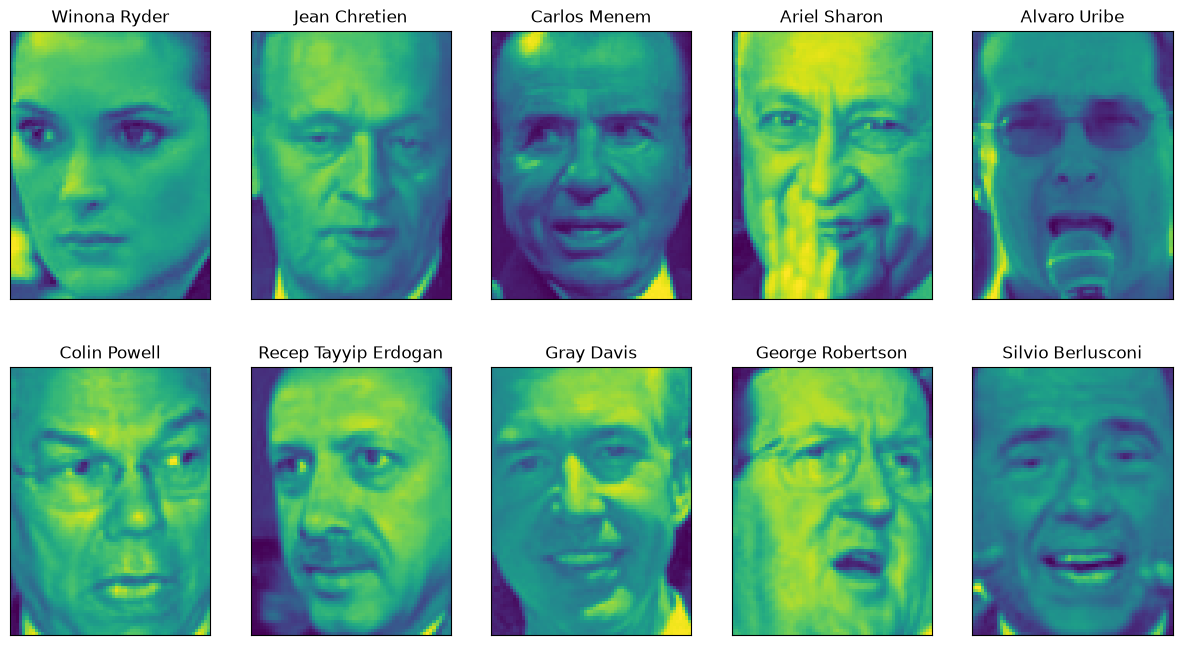

In [19]:
fix,axes=plt.subplots(2,5,figsize=(15,8),subplot_kw={'xticks':(),'yticks':()})
for target,image,ax in zip(people.target,people.images,axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(people.data,people.target, test_size=0.2, random_state=20) 
y_train = y_train.astype(int) 
y_test = y_test.astype(int) 
batch_size = len(X_train) 
print(X_train.shape,y_train.shape,y_test.shape) 
print("people.images.shape: {}".format(people.images.shape)) 
print("Number of classes: {}".format(len(people.target_names))) 

(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [9]:
count = np.bincount(people.target) 
for i, (count, name) in enumerate(zip(count, people.target_names)): 
    print( "{0:25} {1:3}".format(name,count),end=" ") 
    if (i+1)%3 == 0: 
        print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [11]:
mask = np.zeros(people.target.shape,dtype=np.bool_) 
for target in np.unique(people.target): 
    mask[np.where(people.target == target)[0][:50]] = True 
X_people = people.data[mask] 
y_people = people.target[mask]  
X_people = X_people / 255.0 

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_people,y_people,stratify=y_people,random_state=0) 
knn = KNeighborsClassifier(n_neighbors=1) 
knn.fit( X_train, y_train) 
print( "Test set score of 1-nn: {:.2f}".format(knn.score(X_test,y_test)))



Test set score of 1-nn: 0.22


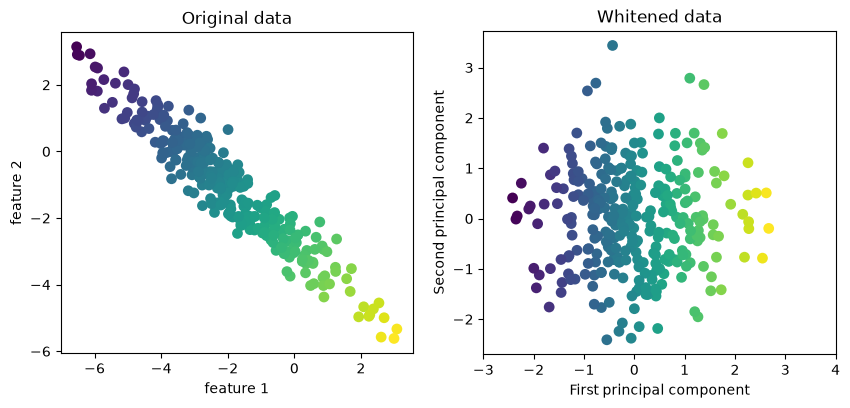

In [13]:
mglearn.plots.plot_pca_whitening() 
plt.show() 


In [14]:
pca = PCA(n_components=100,whiten=True,random_state=0).fit(X_train) 
X_train_pca = pca.transform(X_train) 
X_test_pca = pca.transform(X_test) 
print("X_train_pca.shape: {}".format(X_train_pca.shape)) 
# KNN with PCA 
knn = KNeighborsClassifier(n_neighbors=1) 
knn.fit(X_train_pca,y_train) 
print("Test set accuracy: {:.2f}".format(knn.score(X_test_pca,y_test))) 
print("pca.components_.shape: {}".format(pca.components_.shape)) 


X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


In [15]:
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform( X_train_pca) 
X_test_scaled = scaler.transform(X_test_pca)


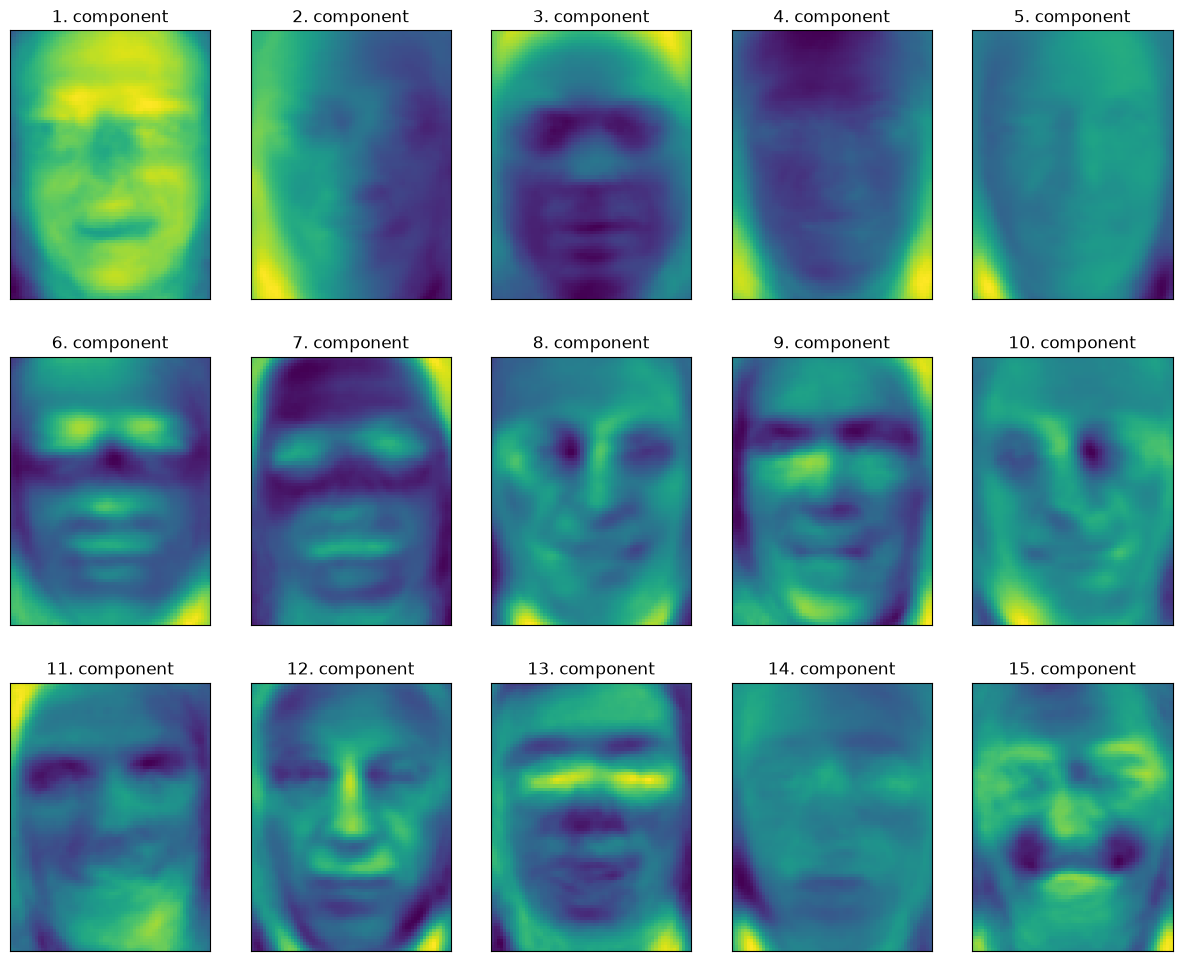

In [16]:
fix, axes = plt.subplots(3,5,figsize=(15,12), subplot_kw={'xticks':(), 'yticks':()}) 
for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())): 
    ax.imshow(component.reshape(image_shape),cmap='viridis') 
    ax.set_title("{}. component".format(i+1)) 
plt.show() 


In [17]:
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform( X_train_pca) 
X_test_scaled = scaler.transform(X_test_pca)


In [19]:
model = Sequential([Input(shape=(100,)),Dense(300,activation='relu'),Dense(100,activation='relu'),Dense( len(np.unique(y_train)),activation='softmax')]) 


In [20]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


In [21]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False, verbose=1) 


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0162 - loss: 4.1302       
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0278 - loss: 4.0890 
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0407 - loss: 4.0616 
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0511 - loss: 4.0362 
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0672 - loss: 4.0110 
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0963 - loss: 3.9783 
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0995 - loss: 3.9394 
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1170 - loss: 3.8895 
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1409 - loss: 3.8267 
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1791 - loss: 3.7485 
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1881 - loss: 3.6506 
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accu

In [22]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1) 
print("Test Loss:", loss) 
print("Test Accuracy:", accuracy) 

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2810 - loss: 2.9893 
Test Loss: 2.989264726638794
Test Accuracy: 0.2810077667236328
